<a href="https://colab.research.google.com/github/Tienndat2306/TH_DeepLearning_Tuan3/blob/main/ANN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

Tải dữ liệu

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)


Trực quan dữ liệu

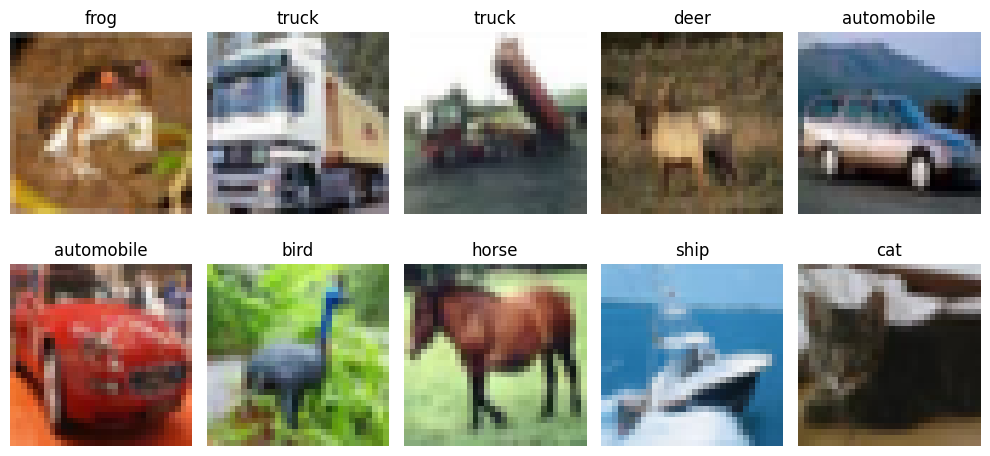

In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Xử lý dữ liệu

In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

y_train_cat shape: (50000, 10)
y_test_cat shape : (10000, 10)


Xây dựng mô hình

In [15]:
model = Sequential()

# Chuyển ảnh 32x32x3 thành vector 3072
model.add(Flatten(input_shape=(32, 32, 3)))

# Hidden layer 1
model.add(Dense(units=1024, activation="relu"))
BatchNormalization(),
model.add(Dropout(0.4))

# Hidden layer 2
model.add(Dense(units=521, activation="relu"))
BatchNormalization(),
model.add(Dropout(0.3))

# Hidden layer 3
model.add(Dense(units=256, activation="relu"))
BatchNormalization(),
model.add(Dropout(0.3))

# Output layer: 10 class
model.add(Dense(units=10, activation="softmax"))

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 521)            │       534,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 521)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       133,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,816,979 (14.56 MB)

 Trainable params: 3,816,979 (14.56 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [16]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks = callbacks
)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\n========== Evaluation Result ==========")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2129 - loss: 2.1026 - val_accuracy: 0.2856 - val_loss: 1.9698 - learning_rate: 0.0010
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2607 - loss: 1.9719 - val_accuracy: 0.2982 - val_loss: 1.9295 - learning_rate: 0.0010
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2851 - loss: 1.9291 - val_accuracy: 0.3268 - val_loss: 1.9086 - learning_rate: 0.0010
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2975 - loss: 1.8977 - val_accuracy: 0.3308 - val_loss: 1.8529 - learning_rate: 0.0010
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3053 - loss: 1.8865 - val_accuracy: 0.3250 - val_loss: 1.8782 - learning_rate: 0.0010
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3100 - loss: 1.8699 - val_accuracy: 0.3594 - val_loss: 1.8651 - learning_rate: 0.0010
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3172 - loss: 1

Biểu đồ đánh giá

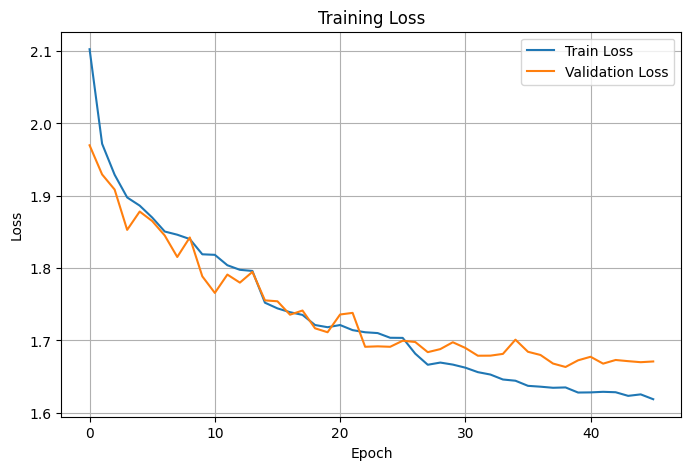

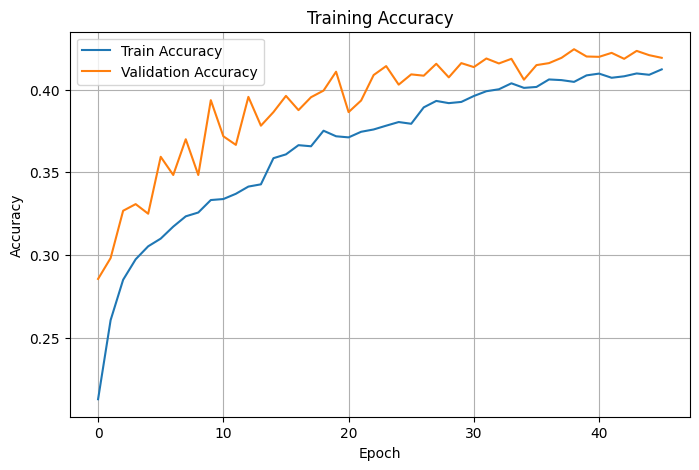

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Dự đoán từ bộ dữ liệu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step


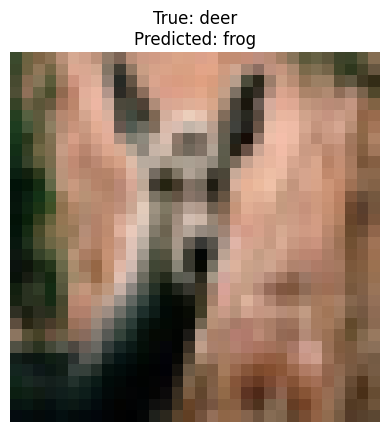

Real label: deer
Predicted result: frog
Prediction probability: 18.524887 %


In [18]:
index = np.random.randint(0, len(X_test))

image = X_test[index]
true_label = y_test[index][0]

prediction = model.predict(image.reshape(1, 32, 32, 3))
predicted_label = np.argmax(prediction)

plt.imshow(image)
plt.title(
    f"True: {class_names[true_label]}\n"
    f"Predicted: {class_names[predicted_label]}"
)
plt.axis("off")
plt.show()

print("Real label:", class_names[true_label])
print("Predicted result:", class_names[predicted_label])
print("Prediction probability:", np.max(prediction) * 100, "%")